# Detection walkthrough — YOLOv8 on classroom stills

Exercises the pipeline in [`detect.py`](detect.py) interactively: locate students in a
classroom image, then inspect what the detector produced.

The notebook calls the same functions as `python -m src.detect.detect`, so anything you
confirm here holds for the command line run too.

**Prerequisites**

- `pip install -r requirements.txt`
- input images in `data/images/input/` (never committed — see `docs/DATA_AND_ETHICS.md`)

## Setup

Locate the repository root and put it on `sys.path`, so the notebook works whether the
kernel starts in this folder or at the repository root.

In [4]:
import sys
from pathlib import Path

REPO_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src').is_dir())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print('Repository root:', REPO_ROOT)

Repository root: /Users/macbook/Documents/EduVisionSeat/EduVisionSeat


In [5]:
import logging

from src.detect import DEFAULT_INPUT_DIR, DEFAULT_OUTPUT_DIR, find_images, run_detection

logging.basicConfig(level=logging.INFO, format='%(levelname)s %(message)s')

print('Input:', DEFAULT_INPUT_DIR)
print('Output:', DEFAULT_OUTPUT_DIR)

ImportError: cannot import name 'DEFAULT_INPUT_DIR' from 'src.detect' (/Users/macbook/Documents/EduVisionSeat/EduVisionSeat/src/detect/__init__.py)

## 1. What is in the input folder?

`find_images` sorts by name and matches suffixes case-insensitively, which is what keeps
runs reproducible: the same `limit` always selects the same images.

In [ ]:
images = find_images(DEFAULT_INPUT_DIR)
print(f'{len(images)} image(s) available')
for path in images[:10]:
    print(' -', path.name)

NameError: name 'find_images' is not defined

## 2. Run the detector

The first call loads the YOLOv8-nano weights from `models/yolov8n.pt`; that import pulls
in the torch stack, so expect a few seconds of startup.

In [ ]:
written = run_detection(limit=3)
written

INFO Loading weights: /Users/macbook/Documents/EduVisionSeat/EduVisionSeat/models/yolov8n.pt
INFO Analyzing 3 image(s) from /Users/macbook/Documents/EduVisionSeat/EduVisionSeat/data/images/input



image 1/1 /Users/macbook/Documents/EduVisionSeat/EduVisionSeat/data/images/input/classroom1.jpg: 480x640 17 persons, 1 chair, 1 couch, 3679.4ms
Speed: 8.4ms preprocess, 3679.4ms inference, 135.8ms postprocess per image at shape (1, 3, 480, 640)


INFO Processed and saved: /Users/macbook/Documents/EduVisionSeat/EduVisionSeat/data/images/output/detected_classroom1.jpg



image 1/1 /Users/macbook/Documents/EduVisionSeat/EduVisionSeat/data/images/input/classroom2.jpg: 480x640 16 persons, 1 tie, 1 cup, 1 dining table, 1 book, 685.7ms
Speed: 7.1ms preprocess, 685.7ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)


INFO Processed and saved: /Users/macbook/Documents/EduVisionSeat/EduVisionSeat/data/images/output/detected_classroom2.jpg



image 1/1 /Users/macbook/Documents/EduVisionSeat/EduVisionSeat/data/images/input/classroom3.jpg: 480x640 13 persons, 1 backpack, 2 chairs, 2 dining tables, 1 laptop, 1 clock, 481.2ms
Speed: 18.3ms preprocess, 481.2ms inference, 16.8ms postprocess per image at shape (1, 3, 480, 640)


INFO Processed and saved: /Users/macbook/Documents/EduVisionSeat/EduVisionSeat/data/images/output/detected_classroom3.jpg


[PosixPath('/Users/macbook/Documents/EduVisionSeat/EduVisionSeat/data/images/output/detected_classroom1.jpg'),
 PosixPath('/Users/macbook/Documents/EduVisionSeat/EduVisionSeat/data/images/output/detected_classroom2.jpg'),
 PosixPath('/Users/macbook/Documents/EduVisionSeat/EduVisionSeat/data/images/output/detected_classroom3.jpg')]

## 3. Inspect the annotated output

Side-by-side original and annotated image. Faces stay identifiable in these outputs, so
clear the notebook outputs before committing (`jupyter nbconvert --clear-output`).

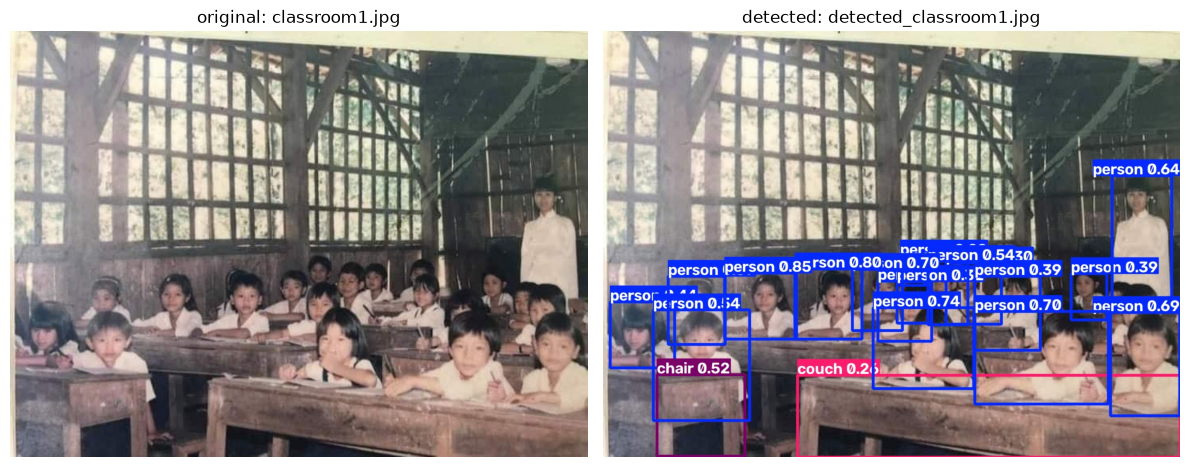

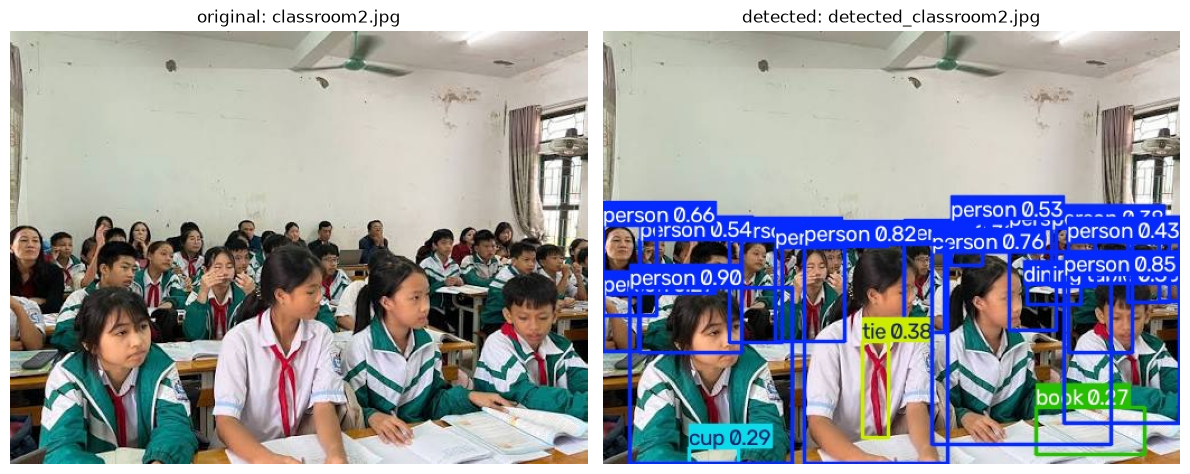

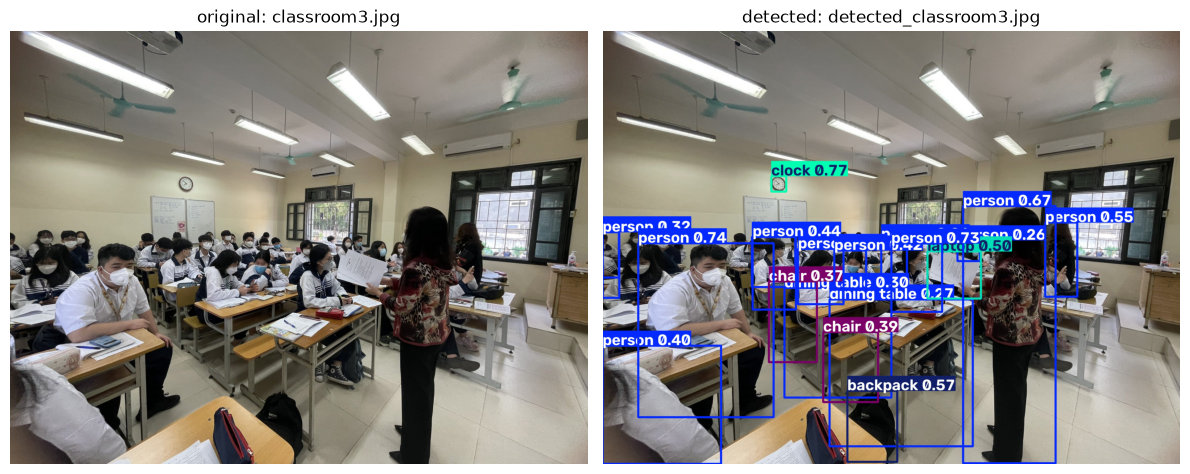

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.image import imread

sources = find_images(DEFAULT_INPUT_DIR, limit=len(written))
for source, annotated in zip(sources, written, strict=True):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, path, title in zip(axes, (source, annotated), ('original', 'detected'), strict=True):
        ax.imshow(imread(path))
        ax.set_title(f'{title}: {path.name}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## 4. Detection details per image

`run_detection` writes files; when you need the raw boxes and classes, drive the model
directly. `person` detections are the ones that matter for seating analysis.

In [ ]:
from src.detect import load_model

model = load_model()
for result in model(str(images[0])):
    names = result.names
    for box in result.boxes:
        label = names[int(box.cls)]
        xyxy = [round(v, 1) for v in box.xyxy[0].tolist()]
        print(f'{label:<12} confidence={float(box.conf):.2f} xyxy={xyxy}')

INFO Loading weights: /Users/macbook/Documents/EduVisionSeat/EduVisionSeat/models/yolov8n.pt



image 1/1 /Users/macbook/Documents/EduVisionSeat/EduVisionSeat/data/images/input/classroom1.jpg: 480x640 17 persons, 1 chair, 1 couch, 265.7ms
Speed: 7.9ms preprocess, 265.7ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)
person       confidence=0.85 xyxy=[229.0, 454.5, 364.0, 578.3]
person       confidence=0.80 xyxy=[361.8, 446.6, 487.9, 578.3]
person       confidence=0.74 xyxy=[508.7, 519.9, 697.9, 672.0]
person       confidence=0.70 xyxy=[699.8, 526.4, 950.6, 700.5]
person       confidence=0.70 xyxy=[469.3, 447.7, 563.4, 562.3]
person       confidence=0.69 xyxy=[954.4, 528.8, 1084.6, 722.6]
person       confidence=0.64 xyxy=[957.6, 271.1, 1069.5, 510.1]
person       confidence=0.57 xyxy=[123.1, 460.3, 230.5, 588.6]
person       confidence=0.54 xyxy=[95.6, 523.2, 276.5, 731.0]
person       confidence=0.54 xyxy=[611.3, 432.1, 686.6, 552.0]
chair        confidence=0.52 xyxy=[102.4, 645.3, 267.5, 798.3]
person       confidence=0.44 xyxy=[14.6, 508.6, 135.8, 632.2]
pe

## Next steps

Detection gives *where a person is in the frame*. The research questions need *which seat
that person occupies*, so the next layer maps boxes onto the classroom chart and tracks
each student across video frames. See the roadmap in the top-level `README.md`.